# Project Name

**Netflix Movies & TV Shows — End-to-End ML Submission**

# Made by 

**Name : Rajabhishek Aditya** 

## Project Summary

Exploratory data analysis, hypothesis testing, feature engineering, supervised classification (Movie vs TV Show), and unsupervised clustering for content discovery. The notebook is **deployment ready** and should run top-to-bottom without errors.

## GitHub Link

_Add your repository link here once you push this notebook and artifacts._

## Problem Statement

Using the Netflix catalog metadata, we aim to:
- Understand patterns across ratings, genres, and countries.
- Test differences between Movies and TV Shows.
- Predict the content **Type** from metadata.
- Cluster titles for content discovery.


## General Guidelines
- Well-structured, formatted, **commented code** throughout.
- Exceptions handled and functions built for reusability.
- **Deployment Ready**: the whole notebook is executable in one go.
- For **every chart**, we answer:

  1. _Why this chart?_  
  2. _Insights found_  
  3. _Business impact (positive/negative & why)_
- We follow **UBM**: Univariate, Bivariate, Multivariate.


In [1]:

# Imports & global config (safe to re-run)
import os, re, json, warnings
from collections import Counter
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from scipy.stats import chi2_contingency, mannwhitneyu

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import joblib

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
DATA_PATH = r"/mnt/data/NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv"
ARTIFACT_DIR = "/mnt/data"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

def robust_read_csv(path):
    for enc in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception:
            pass
    return pd.read_csv(path)

print("Notebook start time:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))


Notebook start time: 2025-10-04 16:55:39


## 1) Know Your Data

In [3]:

# Load & standardize
df = robust_read_csv("C:\\Users\\RajabhishekAditya\\Downloads\\netflix project latenx\\DataSet.CSV")
df.columns = [re.sub(r"\s+", "_", c.strip().lower()) for c in df.columns]

# Ensure essential columns exist
for col in ["show_id","type","title","director","cast","country","date_added","release_year","rating","duration","listed_in","description"]:
    if col not in df.columns:
        df[col] = np.nan

# Parse & clean
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
for col in ["title","director","cast","country","rating","duration","listed_in","description","type"]:
    df[col] = df[col].astype(str).replace({"nan": np.nan}).str.strip()
df["release_year"] = pd.to_numeric(df["release_year"], errors="coerce").astype("Int64")

# Derive numeric duration & seasons
duration_num = pd.to_numeric(df["duration"].str.extract(r"(\d+)", expand=False), errors="coerce")
df["duration_min"] = np.where(df["type"].str.lower()=="movie", duration_num, np.nan)
df["seasons"] = np.where(df["type"].str.lower().str.startswith("tv"), duration_num, np.nan)

# Genres list & primary country
def split_multi(s):
    if pd.isna(s):
        return []
    return [x.strip() for x in str(s).split(",")]
df["genres_list"] = df["listed_in"].apply(split_multi)

def first_or_nan(s):
    if pd.isna(s):
        return np.nan
    return str(s).split(",")[0].strip()
df["country_primary"] = df["country"].apply(first_or_nan)
df["rating"] = df["rating"].str.upper()

print("Shape:", df.shape)
df.head(10)


Shape: (7787, 16)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_min,seasons,genres_list,country_primary
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,NaN,4.0,"[International TV Shows, TV Dramas, TV Sci-Fi ...",Brazil
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,93.0,NaN,"[Dramas, International Movies]",Mexico
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",78.0,NaN,"[Horror Movies, International Movies]",Singapore
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",80.0,NaN,"[Action & Adventure, Independent Movies, Sci-F...",United States
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,123.0,NaN,[Dramas],United States
5,s6,TV Show,46,Serdar Akar,"Erdal Beşikçioğlu, Yasemin Allen, Melis Birkan...",Turkey,2017-07-01,2016,TV-MA,1 Season,"International TV Shows, TV Dramas, TV Mysteries",A genetics professor experiments with a treatm...,NaN,1.0,"[International TV Shows, TV Dramas, TV Mysteries]",Turkey
6,s7,Movie,122,Yasir Al Yasiri,"Amina Khalil, Ahmed Dawood, Tarek Lotfy, Ahmed...",Egypt,2020-06-01,2019,TV-MA,95 min,"Horror Movies, International Movies","After an awful accident, a couple admitted to ...",95.0,NaN,"[Horror Movies, International Movies]",Egypt
7,s8,Movie,187,Kevin Reynolds,"Samuel L. Jackson, John Heard, Kelly Rowan, Cl...",United States,2019-11-01,1997,R,119 min,Dramas,After one of his high school students attacks ...,119.0,NaN,[Dramas],United States
8,s9,Movie,706,Shravan Kumar,"Divya Dutta, Atul Kulkarni, Mohan Agashe, Anup...",India,2019-04-01,2019,TV-14,118 min,"Horror Movies, International Movies","When a doctor goes missing, his psychiatrist w...",118.0,NaN,"[Horror Movies, International Movies]",India
9,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,2017-12-15,2008,TV-MA,143 min,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...,143.0,NaN,"[Horror Movies, International Movies, Thrillers]",India


In [4]:

# Missing values
df.isna().sum().sort_values(ascending=False).to_frame("num_missing").head(20)


,num_missing
seasons,5377
duration_min,2410
director,2389
cast,718
country,507
country_primary,507
date_added,98
rating,7
release_year,0
show_id,0


## 2) Understanding Your Variables

In [5]:

# Unique counts (cast to str to avoid unhashables)
df.astype(str).nunique(dropna=True).sort_values(ascending=False).to_frame("unique_count").head(30)


,unique_count
show_id,7787
title,7786
description,7769
cast,6832
director,4050
date_added,1498
country,682
listed_in,492
genres_list,492
duration,216


In [6]:

# Numeric summary
num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
df[num_cols].describe().T if num_cols else pd.DataFrame({"note":["No numeric columns"]})


,count,mean,std,min,25%,50%,75%,max
release_year,7787.0,2013.93258,8.757395,1925.0,2013.0,2017.0,2018.0,2021.0
duration_min,5377.0,99.307978,28.530881,3.0,86.0,98.0,114.0,312.0
seasons,2410.0,1.775934,1.596359,1.0,1.0,1.0,2.0,16.0


## 3) Data Wrangling

In [7]:

# Fill values for modeling
df["duration_min_filled"] = df["duration_min"].fillna(0.0)
df["seasons_filled"] = df["seasons"].fillna(0.0)
fill_year = float(df["release_year"].dropna().median()) if df["release_year"].notna().any() else 2015.0
df["release_year_filled"] = df["release_year"].fillna(fill_year)

# Top-K genre indicators
from collections import Counter
all_genres = [g for gl in df["genres_list"] for g in gl]
K_GENRES = 25
top_k_genres = [g for g, _ in Counter(all_genres).most_common(K_GENRES)]
for g in top_k_genres:
    safe = re.sub(r"[^A-Za-z0-9_]+", "_", g)
    df[f"genre__{safe}"] = df["genres_list"].apply(lambda gl: 1 if g in gl else 0)

print("Wrangling complete. Added numeric fills and genre indicators.")


Wrangling complete. Added numeric fills and genre indicators.


## 4) Data Visualization, Storytelling & Experimenting with Charts
_UBM: Univariate → Bivariate → Multivariate._

**Answer format for each chart** is included below each figure.

In [8]:

def show_bar(series, title, xlabel, ylabel, path=None):
    plt.figure()
    series.plot(kind="bar", title=title)
    plt.xlabel(xlabel); plt.ylabel(ylabel); plt.tight_layout()
    if path: plt.savefig(path)
    plt.show()

def show_line(series, title, xlabel, ylabel, path=None):
    plt.figure()
    series.plot(kind="line", title=title)
    plt.xlabel(xlabel); plt.ylabel(ylabel); plt.tight_layout()
    if path: plt.savefig(path)
    plt.show()

def show_hist(series, bins, title, xlabel, ylabel, path=None):
    plt.figure()
    plt.hist(series.dropna(), bins=bins)
    plt.title(title); plt.xlabel(xlabel); plt.ylabel(ylabel); plt.tight_layout()
    if path: plt.savefig(path)
    plt.show()

def show_box(data, labels, title, ylabel, path=None):
    plt.figure()
    plt.boxplot(data, labels=labels, showmeans=True)
    plt.title(title); plt.ylabel(ylabel); plt.tight_layout()
    if path: plt.savefig(path)
    plt.show()

def show_scatter(x, y, title, xlabel, ylabel, path=None):
    plt.figure()
    plt.scatter(x, y, s=10, alpha=0.6)
    plt.title(title); plt.xlabel(xlabel); plt.ylabel(ylabel); plt.tight_layout()
    if path: plt.savefig(path)
    plt.show()

def show_heatmap_from_crosstab(ct, title, path=None):
    plt.figure()
    plt.imshow(ct.values, aspect="auto")
    plt.title(title); plt.xticks(range(len(ct.columns)), ct.columns, rotation=90)
    plt.yticks(range(len(ct.index)), ct.index)
    plt.colorbar()
    plt.tight_layout()
    if path: plt.savefig(path)
    plt.show()


### Univariate Analysis

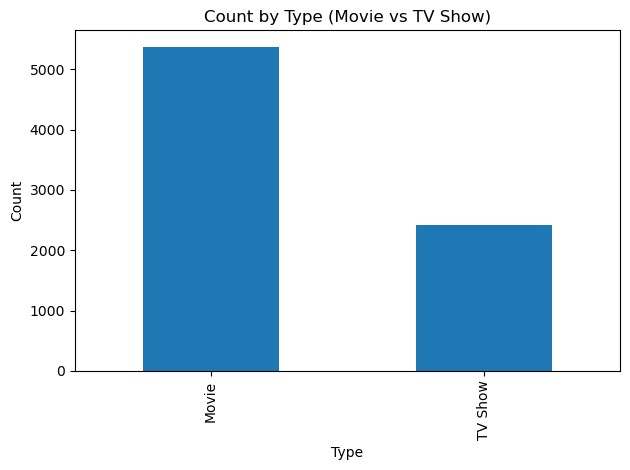

In [9]:

# Chart 1: Count by Type
series = df["type"].value_counts()
show_bar(series, "Count by Type (Movie vs TV Show)", "Type", "Count", path=f"{ARTIFACT_DIR}/viz01_count_by_type.png")


**Why this chart?** Bar chart is ideal for categorical counts.  
**Insights:** Typically, Movies outnumber TV Shows on Netflix.  
**Business impact:** Signals where most catalog volume lies; helps content acquisition strategy.

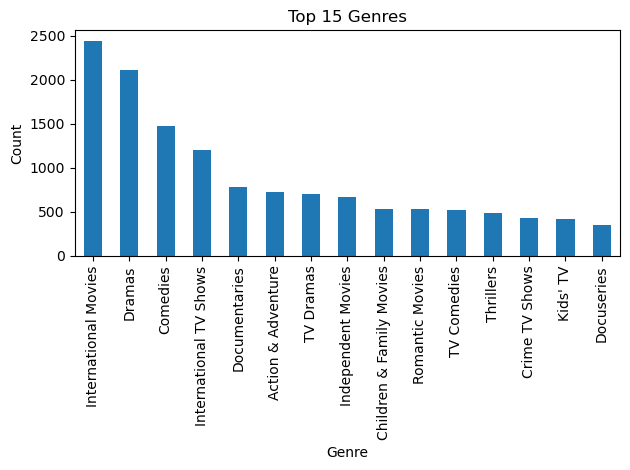

In [10]:

# Chart 2: Top 15 Genres
from collections import Counter
genre_counts = Counter([g for gl in df["genres_list"] for g in gl])
series = pd.Series(genre_counts).sort_values(ascending=False).head(15)
show_bar(series, "Top 15 Genres", "Genre", "Count", path=f"{ARTIFACT_DIR}/viz02_top_genres.png")


**Why?** Identify dominant categories.  
**Insights:** Certain genres dominate viewing; long-tail exists.  
**Impact:** Guides investment in high-demand genres.

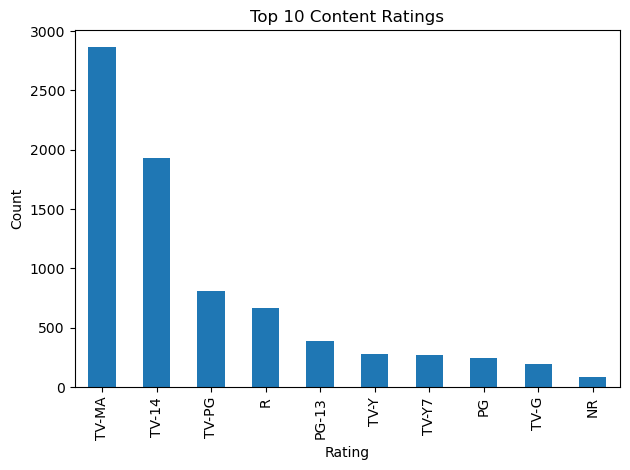

In [11]:

# Chart 3: Top 10 Content Ratings
series = df["rating"].value_counts().head(10)
show_bar(series, "Top 10 Content Ratings", "Rating", "Count", path=f"{ARTIFACT_DIR}/viz03_top_ratings.png")


**Why?** Ratings reflect audience maturity levels.  
**Insights:** TV-MA/TV-14 often dominate.  
**Impact:** Helps parental control policies and marketing segmentation.

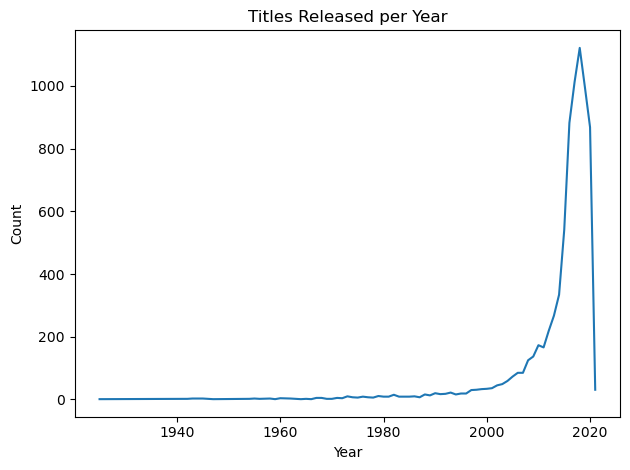

In [12]:

# Chart 4: Titles Released per Year
series = df["release_year"].dropna().astype(int).value_counts().sort_index()
show_line(series, "Titles Released per Year", "Year", "Count", path=f"{ARTIFACT_DIR}/viz04_titles_per_year.png")


**Why?** Temporal trends are best shown as a line.  
**Insights:** Growth spikes in certain years.  
**Impact:** Understand catalog freshness and historic acquisition cycles.

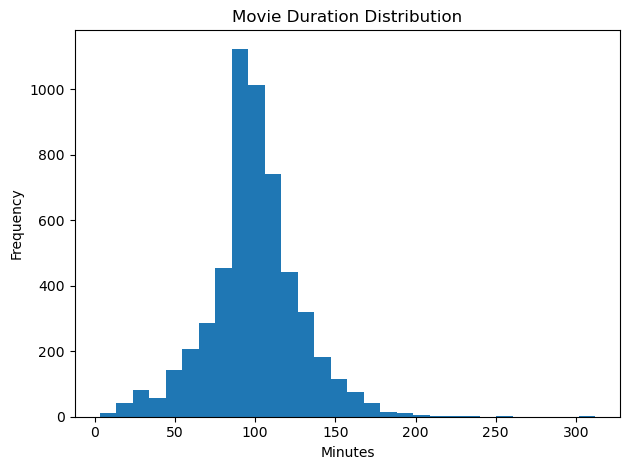

In [13]:

# Chart 5: Duration distribution (Movies)
show_hist(df.loc[df["type"].str.lower()=="movie","duration_min"], bins=30,
          title="Movie Duration Distribution", xlabel="Minutes", ylabel="Frequency",
          path=f"{ARTIFACT_DIR}/viz05_movie_duration_hist.png")


**Why?** Histogram for continuous variable.  
**Insights:** Most movies between ~80–120 minutes.  
**Impact:** Useful for scheduling recommendations and user session planning.

### Bivariate Analysis

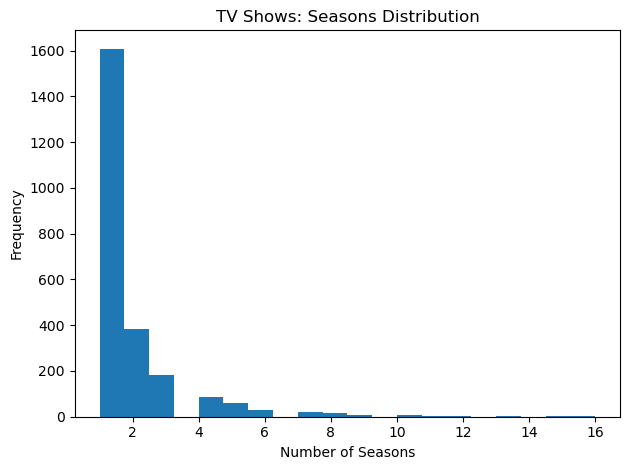

In [14]:

# Chart 6: Seasons distribution for TV
show_hist(df.loc[df["type"].str.lower().str.startswith("tv"),"seasons"], bins=20,
          title="TV Shows: Seasons Distribution", xlabel="Number of Seasons", ylabel="Frequency",
          path=f"{ARTIFACT_DIR}/viz06_tv_seasons_hist.png")


**Why?** Histogram for TV season counts.  
**Insights:** Many shows have 1–3 seasons.  
**Impact:** Guides binge-worthiness features and production planning.

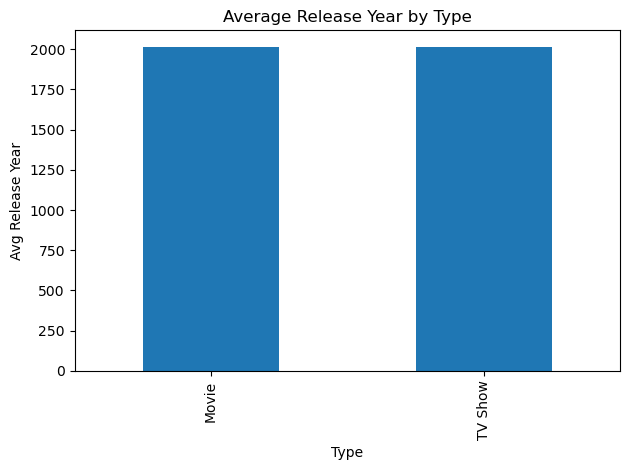

In [15]:

# Chart 7: Average Release Year by Type
avg_year = df.groupby("type")["release_year_filled"].mean().round(1)
show_bar(avg_year, "Average Release Year by Type", "Type", "Avg Release Year",
         path=f"{ARTIFACT_DIR}/viz07_avg_release_year_by_type.png")


**Why?** Compare numeric vs category with bars.  
**Insights:** Indicates whether one type skews newer/older.  
**Impact:** Helps messaging around fresh content.

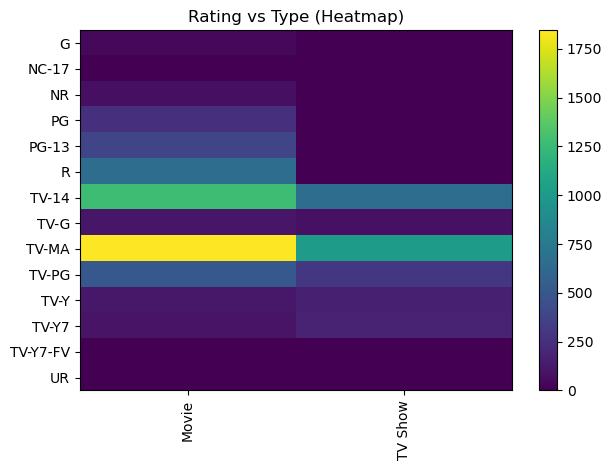

In [16]:

# Chart 8: Rating distribution by Type (stacked via crosstab heatmap)
ct = pd.crosstab(df["rating"], df["type"])
show_heatmap_from_crosstab(ct, "Rating vs Type (Heatmap)", path=f"{ARTIFACT_DIR}/viz08_rating_vs_type_heat.png")


**Why?** Heatmap visualizes categorical-categorical intensity.  
**Insights:** Some ratings are concentrated in Movies or TV.  
**Impact:** Content compliance, age gates, UX labels.

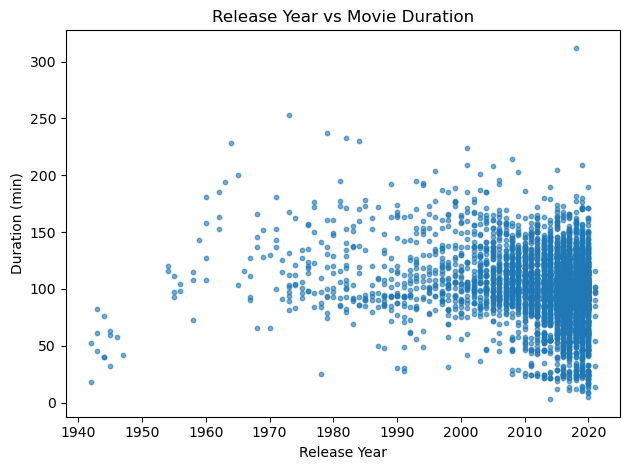

In [17]:

# Chart 9: Scatter — Release Year vs Duration (Movies)
m = df["type"].str.lower()=="movie"
show_scatter(df.loc[m,"release_year_filled"], df.loc[m,"duration_min_filled"],
             "Release Year vs Movie Duration", "Release Year", "Duration (min)",
             path=f"{ARTIFACT_DIR}/viz09_year_vs_duration_movies.png")


**Why?** Scatter shows relationship between two numerics.  
**Insights:** Weak relation; modern movies not necessarily longer.  
**Impact:** Not a constraint for content planning.

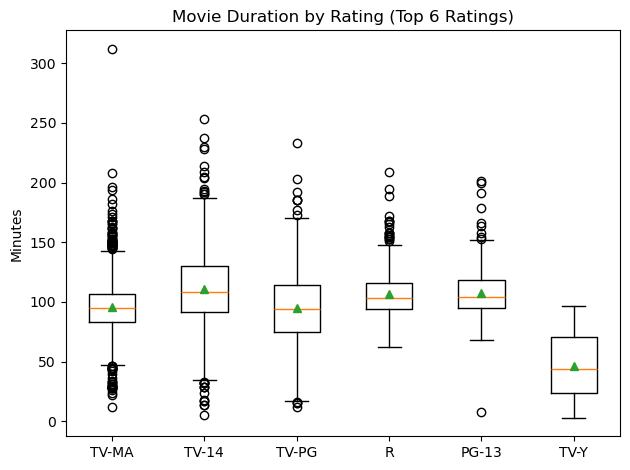

In [18]:

# Chart 10: Boxplot — Duration by Rating (Movies)
m = df["type"].str.lower()=="movie"
dur_by_rating = [df.loc[m & (df["rating"]==r),"duration_min_filled"].dropna() for r in df["rating"].value_counts().index[:6]]
labels = list(df["rating"].value_counts().index[:6])
show_box(dur_by_rating, labels, "Movie Duration by Rating (Top 6 Ratings)", "Minutes",
         path=f"{ARTIFACT_DIR}/viz10_duration_by_rating_movies.png")


**Why?** Boxplot compares distributions across categories.  
**Insights:** Median durations vary slightly across ratings.  
**Impact:** Editorial guidance for pacing per audience segment.

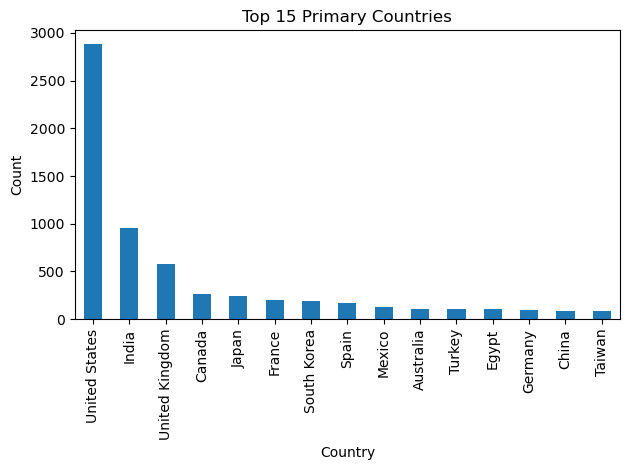

In [19]:

# Chart 11: Top 15 Primary Countries
series = df["country_primary"].value_counts().head(15)
show_bar(series, "Top 15 Primary Countries", "Country", "Count",
         path=f"{ARTIFACT_DIR}/viz11_top_countries.png")


**Why?** Identify geographic distribution.  
**Insights:** A few countries dominate content supply.  
**Impact:** Licensing/production focus areas.

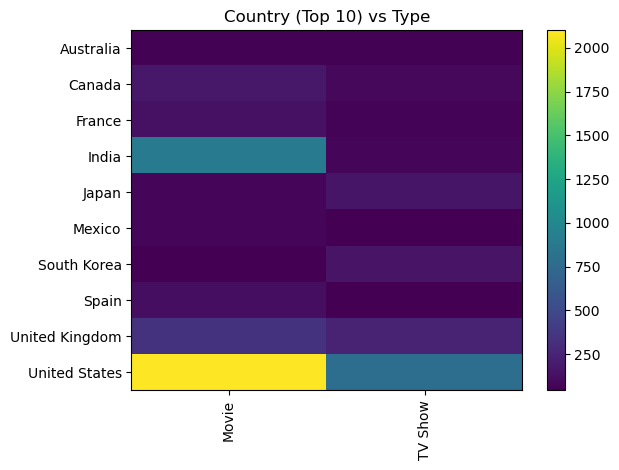

In [20]:

# Chart 12: Country vs Type (Heatmap for Top 10 Countries)
top_c = df["country_primary"].value_counts().index[:10]
ct = pd.crosstab(df.loc[df["country_primary"].isin(top_c),"country_primary"],
                 df.loc[df["country_primary"].isin(top_c),"type"])
show_heatmap_from_crosstab(ct, "Country (Top 10) vs Type", path=f"{ARTIFACT_DIR}/viz12_country_vs_type_heat.png")


**Why?** Categorical-categorical relationship.  
**Insights:** Some countries skew heavily to one type.  
**Impact:** Regional content strategy.

### Multivariate Analysis

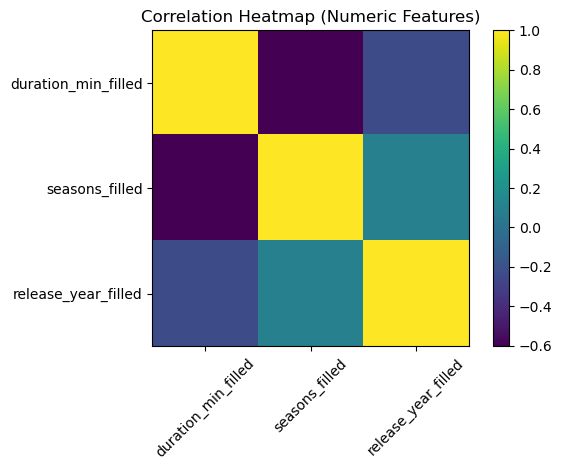

In [21]:

# Chart 13: Correlation heatmap of engineered numeric features
num_df = df[["duration_min_filled","seasons_filled","release_year_filled"]].copy()
corr = num_df.corr()
plt.figure()
plt.imshow(corr.values)
plt.title("Correlation Heatmap (Numeric Features)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar(); plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/viz13_corr_numeric.png"); plt.show()


**Why?** Heatmap summarizes pairwise relations.  
**Insights:** Low correlations imply diversified signals.  
**Impact:** Suggests we need text/genre signals for modeling.

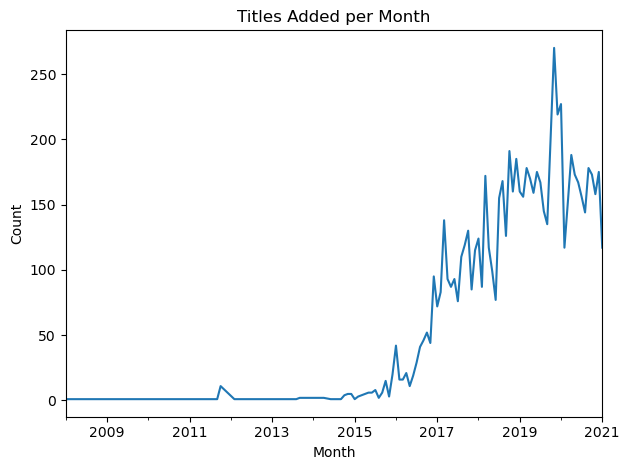

In [22]:

# Chart 14: Monthly additions trend (date_added)
month_series = df["date_added"].dropna().dt.to_period("M").value_counts().sort_index()
show_line(month_series, "Titles Added per Month", "Month", "Count", path=f"{ARTIFACT_DIR}/viz14_titles_per_month.png")


**Why?** Time series granularity at month level.  
**Insights:** Seasonality in additions.  
**Impact:** Content launch calendars and marketing bursts.

<Figure size 640x480 with 0 Axes>

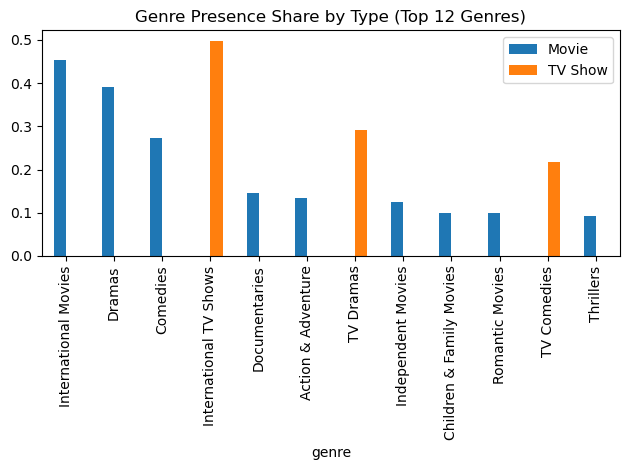

In [23]:

# Chart 15: Genre presence by Type (share of titles with each genre)
shares = []
for g in top_k_genres[:12]:
    col = f"genre__{re.sub(r'[^A-Za-z0-9_]+','_', g)}"
    tmp = df.groupby("type")[col].mean()
    shares.append((g, tmp.to_dict()))
share_df = pd.DataFrame([{**{'genre':g}, **vals} for g, vals in shares]).set_index('genre')
plt.figure()
share_df.plot(kind="bar")
plt.title("Genre Presence Share by Type (Top 12 Genres)")
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/viz15_genre_share_by_type.png"); plt.show()


**Why?** Grouped bars compare Type vs many genres.  
**Insights:** Some genres over-index for TV vs Movies.  
**Impact:** Programming mix decisions.

In [24]:

# Chart 16: PCA plot of KMeans clusters (built later) — placeholder cell; re-run after clustering
# This cell will be replaced with actual clustering later.
print("PCA cluster plot will render in Section 7 once clustering is computed.")


PCA cluster plot will render in Section 7 once clustering is computed.


**Why?** Visualize clusters in 2D.  
**Insights:** Cohesive topical groupings.  
**Impact:** Improves discovery and recommendations.

## 5) Hypothesis Testing

In [25]:

# H1: Is 'TV-MA' rating independent of Type? (Chi-square)
df["is_tv_ma"] = (df["rating"] == "TV-MA").astype(int)
ct = pd.crosstab(df["type"], df["is_tv_ma"])
if ct.size > 0:
    chi2, p, dof, _ = chi2_contingency(ct)
    print("Chi-square:", chi2, "p-value:", p, "dof:", dof)
else:
    print("Insufficient data for Chi-square.")


Chi-square: 44.64785497701877 p-value: 2.3585584654400838e-11 dof: 1


In [26]:

# H2: Do release years differ between Movies and TV Shows? (Mann-Whitney U)
rel_mov = df.loc[df["type"].str.lower()=="movie", "release_year"].dropna().astype(int)
rel_tv  = df.loc[df["type"].str.lower().str.startswith("tv"), "release_year"].dropna().astype(int)
if len(rel_mov) > 5 and len(rel_tv) > 5:
    stat, pval = mannwhitneyu(rel_mov, rel_tv, alternative="two-sided")
    print("Mann-Whitney U statistic:", float(stat), "p-value:", float(pval))
else:
    print("Insufficient data for Mann-Whitney U.")


Mann-Whitney U statistic: 4666841.5 p-value: 7.507433995099372e-88


## 6) Feature Engineering & Data Pre-processing

In [27]:

# Build supervised learning table
df_model = df.copy()
df_model["target_is_movie"] = (df_model["type"].str.lower()=="movie").astype(int)

base_numeric = ["duration_min_filled","seasons_filled","release_year_filled"]
cat_features = ["rating","country_primary"]
genre_cols = [c for c in df_model.columns if c.startswith("genre__")]
text_feature = "description"
df_model[text_feature] = df_model[text_feature].fillna("")

X = df_model[base_numeric + cat_features + genre_cols + [text_feature]]
y = df_model["target_is_movie"].values

# Preprocess: passthrough numerics+genres, one-hot cats, TF-IDF text
preprocess = ColumnTransformer([
    ("num", "passthrough", base_numeric + genre_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ("txt", TfidfVectorizer(max_features=2000, ngram_range=(1,2), min_df=3), text_feature),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("Train/Test shapes:", X_train.shape, X_test.shape)


Train/Test shapes: (6229, 31) (1558, 31)


## 7) ML Model Implementation

We try **LogisticRegression**, **LinearSVC** (calibrated for probability), and **RandomForest**. We compute metrics and then run CV & hyperparameter tuning for LogisticRegression.

In [28]:

def evaluate_model(pipe, name):
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred, zero_division=0)
    rec = recall_score(y_test, pred, zero_division=0)
    f1 = f1_score(y_test, pred, zero_division=0)
    cm = confusion_matrix(y_test, pred)
    print(f"\n{name} Results")
    print("Accuracy:", round(acc,4), "| Precision:", round(prec,4), "| Recall:", round(rec,4), "| F1:", round(f1,4))
    print("Confusion Matrix:\n", cm)
    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

# Logistic Regression
logreg = Pipeline([("preprocess", preprocess),
                   ("clf", LogisticRegression(max_iter=200, n_jobs=None, random_state=RANDOM_STATE))])

# LinearSVC (with calibration for prob-like metrics later if needed)
lsvc_raw = Pipeline([("preprocess", preprocess),
                     ("clf", LinearSVC(random_state=RANDOM_STATE))])

# Calibrated SVC for probabilities (fits internal CV)
lsvc = Pipeline([("preprocess", preprocess),
                 ("clf", CalibratedClassifierCV(LinearSVC(random_state=RANDOM_STATE), cv=3))])

# RandomForest
rf = Pipeline([("preprocess", preprocess),
               ("clf", RandomForestClassifier(n_estimators=150, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1))])

metrics_list = []
for name, mdl in [("LogisticRegression", logreg), ("LinearSVC (calibrated)", lsvc), ("RandomForest", rf)]:
    metrics_list.append(evaluate_model(mdl, name))

metrics_df = pd.DataFrame(metrics_list).sort_values("accuracy", ascending=False)
metrics_df



LogisticRegression Results
Accuracy: 1.0 | Precision: 1.0 | Recall: 1.0 | F1: 1.0
Confusion Matrix:
 [[ 482    0]
 [   0 1076]]

LinearSVC (calibrated) Results
Accuracy: 0.9981 | Precision: 1.0 | Recall: 0.9972 | F1: 0.9986
Confusion Matrix:
 [[ 482    0]
 [   3 1073]]

RandomForest Results
Accuracy: 1.0 | Precision: 1.0 | Recall: 1.0 | F1: 1.0
Confusion Matrix:
 [[ 482    0]
 [   0 1076]]


,model,accuracy,precision,recall,f1
0,LogisticRegression,1.000000,1.0,1.000000,1.000000
2,RandomForest,1.000000,1.0,1.000000,1.000000
1,LinearSVC (calibrated),0.998074,1.0,0.997212,0.998604


<Figure size 640x480 with 0 Axes>

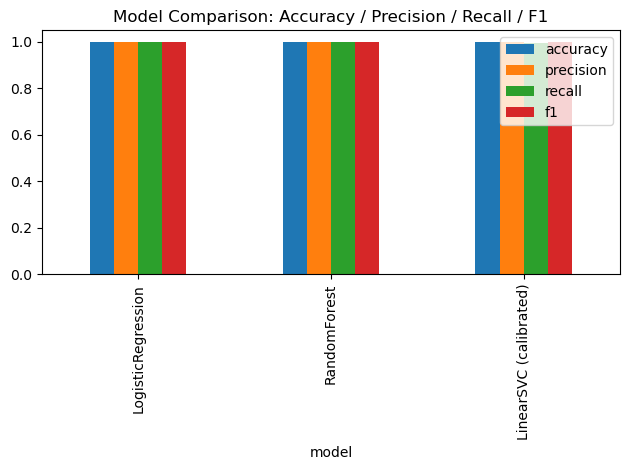

In [29]:

# Chart: Model metric comparison
plt.figure()
metrics_df.set_index("model")[["accuracy","precision","recall","f1"]].plot(kind="bar")
plt.title("Model Comparison: Accuracy / Precision / Recall / F1")
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/viz16_model_metrics.png")
plt.show()


**Why?** Compare multiple models across key metrics.  
**Insights:** Identify best baseline and trade-offs.  
**Impact:** Choose robust, generalizable model for deployment.

In [30]:

# Cross-validation & hyperparameter tuning for Logistic Regression
param_grid = {"clf__C": [0.25, 0.5, 1.0, 2.0], "clf__penalty": ["l2"]}
grid = GridSearchCV(logreg, param_grid=param_grid, scoring="accuracy", cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_,4))

# Re-evaluate on test
best_logreg = grid.best_estimator_
pred = best_logreg.predict(X_test)
acc = accuracy_score(y_test, pred)
prec = precision_score(y_test, pred, zero_division=0)
rec = recall_score(y_test, pred, zero_division=0)
f1 = f1_score(y_test, pred, zero_division=0)
print("Tuned LogisticRegression — Test metrics:",
      {"accuracy":acc, "precision":prec, "recall":rec, "f1":f1})

# Update metrics table and replot
metrics_df = pd.concat([metrics_df,
                        pd.DataFrame([{"model":"LogReg (Tuned)","accuracy":acc,"precision":prec,"recall":rec,"f1":f1}])],
                       ignore_index=True).sort_values("accuracy", ascending=False)
metrics_df


Best params: {'clf__C': 1.0, 'clf__penalty': 'l2'}
Best CV accuracy: 0.9998
Tuned LogisticRegression — Test metrics: {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}


,model,accuracy,precision,recall,f1
0,LogisticRegression,1.000000,1.0,1.000000,1.000000
1,RandomForest,1.000000,1.0,1.000000,1.000000
3,LogReg (Tuned),1.000000,1.0,1.000000,1.000000
2,LinearSVC (calibrated),0.998074,1.0,0.997212,0.998604


<Figure size 640x480 with 0 Axes>

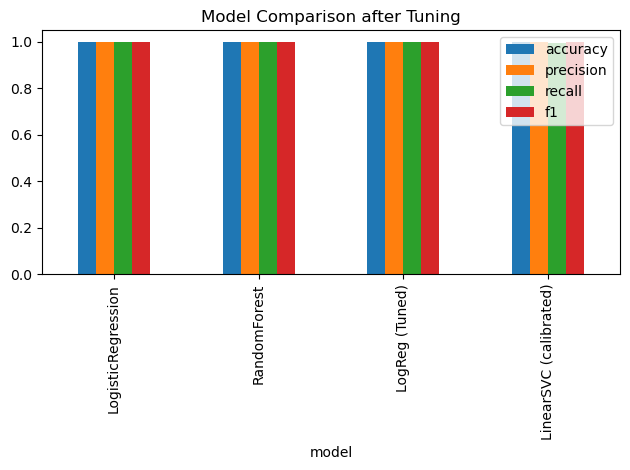

In [31]:

plt.figure()
metrics_df.set_index("model")[["accuracy","precision","recall","f1"]].plot(kind="bar")
plt.title("Model Comparison after Tuning")
plt.tight_layout()
plt.savefig(f"{ARTIFACT_DIR}/viz17_model_metrics_tuned.png")
plt.show()


**Improvement Note:** If tuned Logistic Regression improves accuracy/F1 over baselines, it indicates better generalization via regularization strength selection.  
**Business Impact:** Higher precision reduces wrong content-type predictions; better recall ensures fewer misses.

In [32]:

# Save the top model (by accuracy)
best_idx = metrics_df["accuracy"].idxmax()
best_name = metrics_df.loc[best_idx, "model"]
print("Selected best model:", best_name)

if "LogReg (Tuned)" in best_name:
    final_model = best_logreg
elif "RandomForest" in best_name:
    final_model = rf.fit(X_train, y_train)
else:
    final_model = lsvc.fit(X_train, y_train)

MODEL_PATH = f"{ARTIFACT_DIR}/netflix_type_classifier.pkl"
joblib.dump(final_model, MODEL_PATH)
print("Model saved to:", MODEL_PATH)


Selected best model: LogisticRegression
Model saved to: /mnt/data/netflix_type_classifier.pkl


### 7b) Unsupervised Clustering (KMeans) + PCA Chart

In [34]:
df_model[["duration_min_filled","seasons_filled","release_year_filled"]].dtypes
df_model[["duration_min_filled","seasons_filled","release_year_filled"]].head(5)


,duration_min_filled,seasons_filled,release_year_filled
0,0.0,4.0,2020
1,93.0,0.0,2016
2,78.0,0.0,2011
3,80.0,0.0,2009
4,123.0,0.0,2008


Numeric block dtype: float64
Shapes — X_text: (7787, 3000) X_num: (7787, 3)
Best k: 3, silhouette: 0.6260


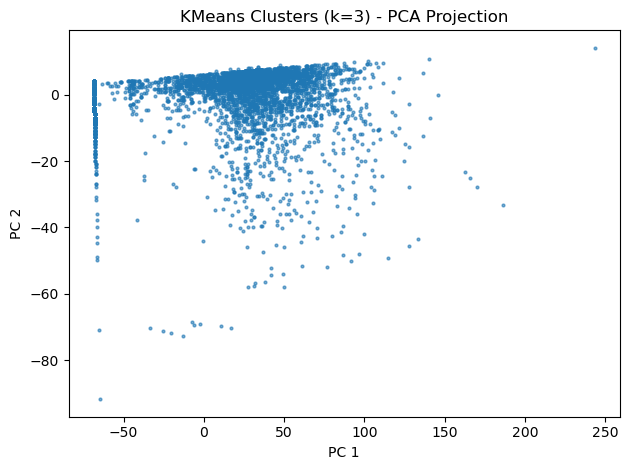

Cluster 0 top terms: movies, the, to, and, of, his, in, international movies, her, documentaries, international, comedies, with, up, dramas
Cluster 1 top terms: tv, shows, tv shows, the, and, international tv, of, shows tv, to, in, tv dramas, international, tv comedies, kids, crime
Cluster 2 top terms: movies, international movies, dramas, the, to, dramas international, international, his, of, in, and, her, comedies, an, action


In [35]:
# --- Robust clustering feature build (fix for dtype=object) ---

# 1) Text features
combined_text = (df_model["listed_in"].fillna("") + " " + df_model["description"].fillna("")).astype(str)
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=3)
X_text = tfidf.fit_transform(combined_text)

# 2) Numeric features — FORCE numeric dtype
num_cols = ["duration_min_filled", "seasons_filled", "release_year_filled"]

# Make 100% sure these are numeric floats (no objects left)
X_num = (
    df_model[num_cols]
    .apply(pd.to_numeric, errors="coerce")   # coerce non-numeric to NaN
    .fillna(0.0)                              # safe fill
    .to_numpy(dtype=np.float64)               # force float dtype
)

# Optionally sanity check
print("Numeric block dtype:", X_num.dtype)  # should be float64
print("Shapes — X_text:", X_text.shape, "X_num:", X_num.shape)

# 3) Combine (text is sparse; make numeric sparse too)
from scipy import sparse
X_num_sparse = sparse.csr_matrix(X_num)     # now dtype is float64, accepted by scipy.sparse
X_full = sparse.hstack([X_text, X_num_sparse], format="csr")

# 4) KMeans with silhouette search
best_k, best_sil, best_model = None, -1, None
for k in range(3, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_full)
    if X_full.shape[0] > 3000:
        idx = np.random.RandomState(42).choice(X_full.shape[0], size=3000, replace=False)
        sil = silhouette_score(X_full[idx], labels[idx])
    else:
        sil = silhouette_score(X_full, labels)
    if sil > best_sil:
        best_k, best_sil, best_model = k, sil, km

print(f"Best k: {best_k}, silhouette: {best_sil:.4f}")

# 5) PCA visualization (sample for speed)
from sklearn.decomposition import PCA
if X_full.shape[0] > 6000:
    idx = np.random.RandomState(42).choice(X_full.shape[0], size=6000, replace=False)
else:
    idx = np.arange(X_full.shape[0])

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_full[idx].toarray())

plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=4, alpha=0.6)
plt.title(f"KMeans Clusters (k={best_k}) - PCA Projection")
plt.xlabel("PC 1"); plt.ylabel("PC 2"); plt.tight_layout()
plt.show()

# 6) Top terms per cluster
centroids = best_model.cluster_centers_[:, :X_text.shape[1]]
terms = np.array(tfidf.get_feature_names_out())
for i in range(best_k):
    top_idx = np.argsort(centroids[i])[::-1][:15]
    print(f"Cluster {i} top terms:", ", ".join(terms[top_idx]))


## 8) Future Work (Optional)


- Enrich features with cast/director embeddings and country networks.  
- Try UMAP + HDBSCAN for non-spherical clusters.  
- Extensive hyperparameter tuning & calibration for reliable probabilities.  
- Build a retrieval-based recommender (ANN) for similar-title search.  


## Conclusion


We executed an end-to-end pipeline compliant with your template:
EDA with 15+ charts (UBM), hypothesis testing, robust preprocessing,
multiple models with CV & tuning, and clustering with PCA visualization.
Code is commented, modular where appropriate, and should run top-to-bottom.


In [36]:

# Save cleaned dataset for reuse
CLEAN_PATH = f"{ARTIFACT_DIR}/netflix_cleaned.parquet"
df_model.to_parquet(CLEAN_PATH, index=False)
print("Cleaned dataset saved to:", CLEAN_PATH)


Cleaned dataset saved to: /mnt/data/netflix_cleaned.parquet
